# Predicting Student Dropout & Academic Success

GSB-S545 Advanced Machine Learning — Group Project Draft Report  
**Team:** Lucas Calaff, Shane Waldron, Tyler Wolf Williams

We predict whether a student will drop out, stay enrolled, or graduate by the end of the normal program duration, using demographic, socioeconomic, application, academic performance, and macroeconomic features captured through the first academic year.

Three models in order of increasing complexity:
1. Stage 1: Multinomial Logistic Regression (interpretable baseline)
2. Stage 2: Tree-Based Ensembles (Random Forest + LightGBM)
3. Stage 3: Feedforward Neural Network

All three use the same evaluation setup — stratified 70/15/15 split, macro-F1 as the primary metric, per-class diagnostics — so comparisons are direct.

## Step 1 — Imports & Setup

Standard ML stack plus sklearn's MLP for the neural network stage. Seeds are fixed across `numpy`, `random`, and `os.environ` for reproducibility; small run-to-run drift is still possible and noted where it matters.

In [1]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_LGBM = False
    print("LightGBM not available — falling back to sklearn GradientBoostingClassifier.")

from sklearn.neural_network import MLPClassifier  # NN stage uses sklearn MLP (no TF dependency)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

print(f"pandas {pd.__version__} | numpy {np.__version__}")


LightGBM not available — falling back to sklearn GradientBoostingClassifier.
pandas 3.0.3 | numpy 2.4.4


## Step 2 — Data Loading & Initial Inspection

The dataset is semicolon-delimited. We strip whitespace from column names (one has a trailing tab), verify no missing values or duplicates, and encode the target as `Dropout=0, Enrolled=1, Graduate=2`.

In [2]:
df = pd.read_csv(r'Data\Student_Data.csv', sep=';')
df.columns = df.columns.str.strip()
print(f"Shape: {df.shape}")
df.head()


Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Sanity checks: dtypes, missingness, duplicates
print("Missing values total:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print("Target distribution:")
print(df['Target'].value_counts(normalize=True).round(4))


Missing values total: 0
Duplicate rows: 0

Target distribution:
Target
Graduate    0.4993
Dropout     0.3212
Enrolled    0.1795
Name: proportion, dtype: float64


In [4]:
# Encode target as integers (ordering chosen to match proposal narrative: 0=Dropout, 1=Enrolled, 2=Graduate)
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
inv_target_map = {v: k for k, v in target_map.items()}
df['target_enc'] = df['Target'].map(target_map)
y_full = df['target_enc'].values
X_full = df.drop(columns=['Target', 'target_enc'])
print("Feature count:", X_full.shape[1])
print("Class counts:", dict(zip(*np.unique(y_full, return_counts=True))))


Feature count: 36
Class counts: {np.int64(0): np.int64(1421), np.int64(1): np.int64(794), np.int64(2): np.int64(2209)}


## Step 3 — Exploratory Data Analysis

EDA here is targeted rather than exhaustive. We focus on the signals flagged as most important in the proposal — academic performance, financial status, and age — plus a correlation heatmap to check redundancy among the curricular-unit columns.

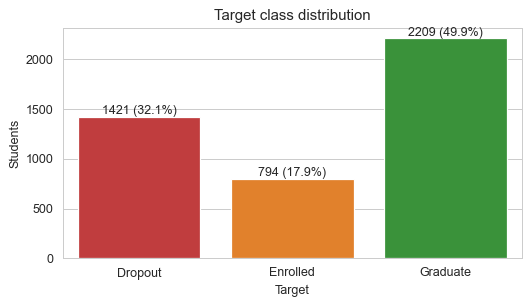

In [5]:
# 3.1 — Class balance
fig, ax = plt.subplots(figsize=(6, 3.5))
order = ['Dropout', 'Enrolled', 'Graduate']
counts = df['Target'].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=['#d62728', '#ff7f0e', '#2ca02c'])
ax.set_title('Target class distribution')
ax.set_ylabel('Students')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f"{v} ({v/len(df)*100:.1f}%)", ha='center')
plt.tight_layout(); plt.show()


Graduate is the plurality (~50%); Enrolled is the smallest class (~18%). Enrolled sits in the middle of the outcome ordering and will likely be the hardest to classify since it falls between the two academic extremes.

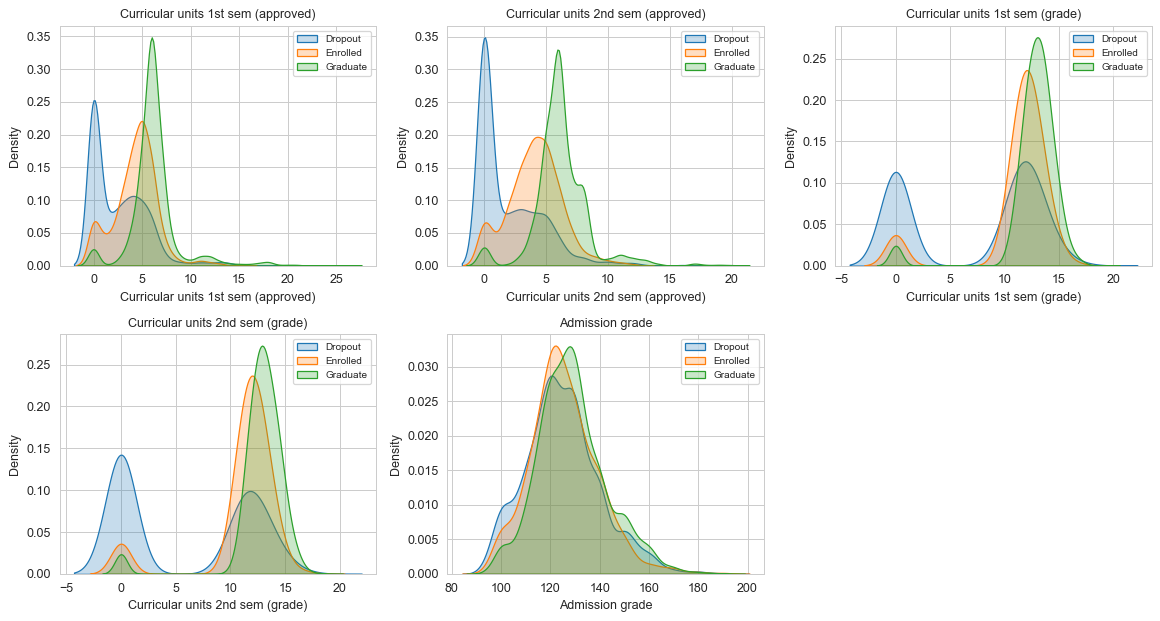

In [6]:
# 3.2 — Academic performance by class (strongest signal per proposal)
academic_cols = [
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Admission grade',
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, academic_cols):
    for cls in order:
        sns.kdeplot(df.loc[df['Target'] == cls, col], ax=ax, label=cls, fill=True, alpha=0.25)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()


Clear class separation in approved units and semester grades, consistent with the proposal's finding that academic performance is the dominant signal. Graduates cluster near full course loads; Dropouts cluster near zero approved units.

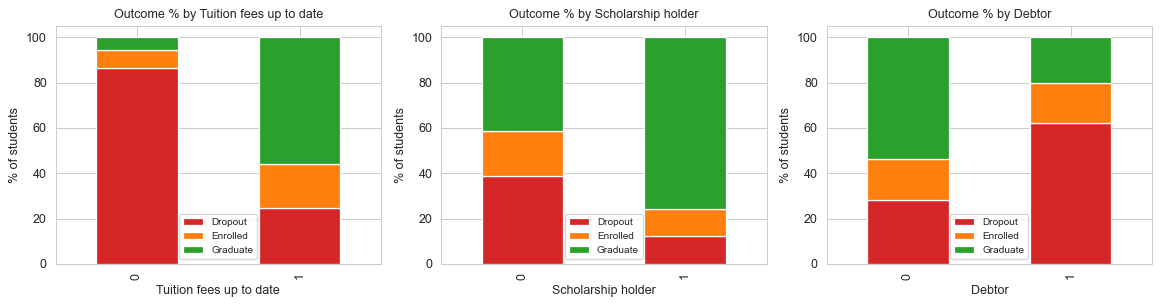

In [7]:
# 3.3 — Financial / socioeconomic signals
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ['Tuition fees up to date', 'Scholarship holder', 'Debtor']):
    ct = pd.crosstab(df[col], df['Target'], normalize='index') * 100
    ct = ct[order]
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c'])
    ax.set_title(f'Outcome % by {col}', fontsize=10)
    ax.set_ylabel('% of students')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


Tuition status is a near-deterministic separator: students not current on tuition graduate at a much lower rate. Scholarship holders graduate disproportionately. Debt status is informative but weaker than tuition.

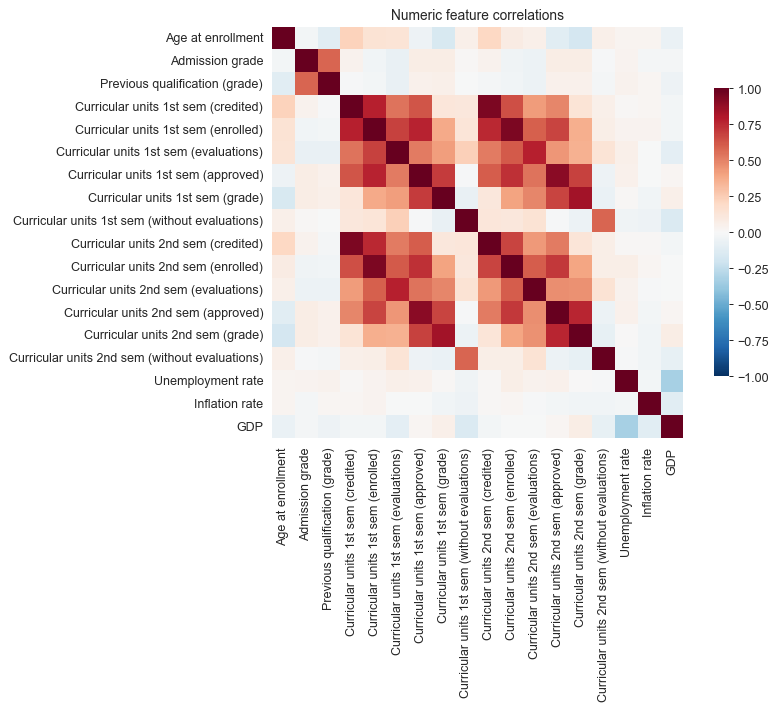

In [8]:
# 3.4 — Correlation heatmap on numeric features
numeric_candidates = [
    'Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP',
]
corr = df[numeric_candidates].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.7})
plt.title('Numeric feature correlations', fontsize=11)
plt.tight_layout(); plt.show()


As expected, the curricular-unit columns cluster tightly (0.4–0.9 correlations across semesters). That redundancy motivates the ratio features in Step 4, which compress the within-block signal into a smaller, more interpretable form.

## Step 4 — Feature Engineering

Four families of features, each designed to be interpretable and reduce reliance on the correlated raw curricular-unit columns:

- Ratio features track semester-over-semester progression (sem2 / sem1 approved units and grades)
- Interaction terms pair a socioeconomic flag with a first-semester academic signal
- Early-warning flags mark students showing risk indicators in semester 1 alone
- Age buckets group the raw age variable into three tiers

In [9]:
def add_engineered_features(df_in):
    X = df_in.copy()
    # Ratio features — +1 smoothing avoids divide-by-zero
    X['sem2_approved_ratio'] = (X['Curricular units 2nd sem (approved)'] + 1) / (X['Curricular units 1st sem (approved)'] + 1)
    X['sem2_grade_ratio']    = (X['Curricular units 2nd sem (grade)']    + 1) / (X['Curricular units 1st sem (grade)']    + 1)
    X['approval_rate_sem1']  = X['Curricular units 1st sem (approved)'] / (X['Curricular units 1st sem (enrolled)'] + 1)
    X['approval_rate_sem2']  = X['Curricular units 2nd sem (approved)'] / (X['Curricular units 2nd sem (enrolled)'] + 1)
    # Interactions
    X['scholarship_x_sem1_grade'] = X['Scholarship holder'] * X['Curricular units 1st sem (grade)']
    X['tuition_x_sem1_approved']  = X['Tuition fees up to date'] * X['Curricular units 1st sem (approved)']
    # Early-warning binary flags
    X['zero_units_sem1'] = (X['Curricular units 1st sem (approved)'] == 0).astype(int)
    X['low_grade_sem1']  = (X['Curricular units 1st sem (grade)'] < 9).astype(int)
    X['not_paying_tuition'] = (X['Tuition fees up to date'] == 0).astype(int)
    # Age bucket
    def age_bucket(a):
        if a < 22: return 0
        if a <= 27: return 1
        return 2
    X['age_bucket'] = X['Age at enrollment'].apply(age_bucket)
    return X

X_full_fe = add_engineered_features(X_full)
new_cols = [c for c in X_full_fe.columns if c not in X_full.columns]
print(f"Added {len(new_cols)} engineered features:")
for c in new_cols: print(f"  - {c}")


Added 10 engineered features:
  - sem2_approved_ratio
  - sem2_grade_ratio
  - approval_rate_sem1
  - approval_rate_sem2
  - scholarship_x_sem1_grade
  - tuition_x_sem1_approved
  - zero_units_sem1
  - low_grade_sem1
  - not_paying_tuition
  - age_bucket


In [10]:
# Quick diagnostic: how strongly does each new feature relate to the target?
diag = pd.DataFrame({'feature': new_cols})
diag['corr_with_target'] = [X_full_fe[c].corr(pd.Series(y_full)) for c in new_cols]
diag['mean_dropout']  = [X_full_fe.loc[y_full == 0, c].mean() for c in new_cols]
diag['mean_graduate'] = [X_full_fe.loc[y_full == 2, c].mean() for c in new_cols]
diag['sep_strength']  = (diag['mean_graduate'] - diag['mean_dropout']).abs()
diag = diag.sort_values('sep_strength', ascending=False)
print(diag.to_string(index=False))


                 feature  corr_with_target  mean_dropout  mean_graduate  sep_strength
 tuition_x_sem1_approved          0.589612      1.824068       6.149389      4.325321
scholarship_x_sem1_grade          0.324670      0.858341       4.790239      3.931899
              age_bucket         -0.289423      0.888811       0.355364      0.533446
      approval_rate_sem2          0.701886      0.252235       0.780719      0.528484
      approval_rate_sem1          0.629786      0.330552       0.782527      0.451975
         zero_units_sem1         -0.428565      0.401126       0.034857      0.366269
          low_grade_sem1         -0.428565      0.401126       0.034857      0.366269
      not_paying_tuition         -0.409827      0.321605       0.013128      0.308476
     sem2_approved_ratio          0.143279      0.902178       1.012736      0.110558
        sem2_grade_ratio         -0.027930      1.076334       1.016962      0.059372


The engineered features show real separation, especially the approval-rate ratios, interaction terms, and early-warning flags. We keep all of them; tree models will naturally downweight anything redundant.

## Step 5 — Preprocessing Pipeline & Splits

Categorical features in this dataset are integer-coded enums rather than ordinal values, so we one-hot encode them. Numeric features are standardized to support LogReg and the NN; scaling doesn't hurt tree models, so one preprocessor covers all three stages.

We use a stratified 70/15/15 train/val/test split. The test set is held out completely and only touched in Step 9.

In [11]:
# Categorical features are integer-coded enums per the data dictionary.
categorical_features = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'International', 'age_bucket',
]
numeric_features = [c for c in X_full_fe.columns if c not in categorical_features]
print(f"{len(categorical_features)} categorical, {len(numeric_features)} numeric")


19 categorical, 27 numeric


In [12]:
# 70/15/15 stratified split (test held out)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full_fe, y_full, test_size=0.15, stratify=y_full, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED)  # 0.1765 ≈ 15/85
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Train class balance:", dict(zip(*np.unique(y_train, return_counts=True))))


Train: (3096, 46), Val: (664, 46), Test: (664, 46)
Train class balance: {np.int64(0): np.int64(995), np.int64(1): np.int64(556), np.int64(2): np.int64(1545)}


In [13]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)
feature_names_p = preprocessor.get_feature_names_out()
print(f"Preprocessed shape: {X_train_p.shape} (features expanded from {X_train.shape[1]} to {X_train_p.shape[1]} after one-hot)")


Preprocessed shape: (3096, 258) (features expanded from 46 to 258 after one-hot)


In [14]:
# Class weights for imbalance handling — used by LR, RF, LGBM, and NN
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(i): float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weight_dict)


Class weights: {0: 1.0371859296482413, 1: 1.856115107913669, 2: 0.6679611650485436}


## Step 6 — Stage 1: Multinomial Logistic Regression Baseline

The linear baseline provides interpretable coefficients and a performance floor. We tune the L2 regularization strength `C` via 5-fold stratified cross-validation on macro-F1.

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lr_grid = GridSearchCV(
    LogisticRegression(solver='lbfgs', class_weight='balanced',
                       max_iter=2000, random_state=SEED),
    param_grid={'C': [0.01, 0.1, 1.0, 10.0]},
    cv=skf, scoring='f1_macro', n_jobs=-1,
)
lr_grid.fit(X_train_p, y_train)
print(f"Best C: {lr_grid.best_params_['C']}")
print(f"Best CV macro-F1: {lr_grid.best_score_:.4f}")
lr_model = lr_grid.best_estimator_


Best C: 0.1
Best CV macro-F1: 0.7153


In [16]:
def report_val(name, y_true, y_pred):
    print(f"\n=== {name} — Validation Set ===")
    print(f"Accuracy:    {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro-F1:    {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Dropout recall: {recall_score(y_true, y_pred, labels=[0], average='macro'):.4f}")
    print(classification_report(y_true, y_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))

y_val_lr = lr_model.predict(X_val_p)
report_val('Logistic Regression', y_val, y_val_lr)



=== Logistic Regression — Validation Set ===
Accuracy:    0.7364
Macro-F1:    0.6969
Dropout recall: 0.7465
              precision    recall  f1-score   support

     Dropout       0.78      0.75      0.76       213
    Enrolled       0.44      0.60      0.51       119
    Graduate       0.87      0.78      0.82       332

    accuracy                           0.74       664
   macro avg       0.70      0.71      0.70       664
weighted avg       0.76      0.74      0.75       664



In [17]:
# Top coefficients per class — interpretability check
coef_df = pd.DataFrame(lr_model.coef_.T, index=feature_names_p, columns=['Dropout', 'Enrolled', 'Graduate'])
for cls in ['Dropout', 'Graduate']:
    top = coef_df[cls].abs().sort_values(ascending=False).head(10).index
    print(f"\nTop 10 features for '{cls}':")
    print(coef_df.loc[top, cls].round(3).to_string())



Top 10 features for 'Dropout':
cat__Mother's occupation_0                  0.539
cat__Course_9853                            0.501
num__approval_rate_sem2                    -0.500
num__Curricular units 1st sem (approved)   -0.492
cat__Course_9130                            0.492
num__approval_rate_sem1                    -0.469
cat__Mother's occupation_191               -0.437
cat__Father's occupation_90                 0.424
cat__Course_171                            -0.423
num__Curricular units 2nd sem (approved)   -0.405

Top 10 features for 'Graduate':
num__Curricular units 2nd sem (approved)    0.771
num__approval_rate_sem2                     0.639
cat__Course_9238                            0.561
cat__Course_9119                           -0.534
num__Curricular units 1st sem (approved)    0.531
cat__Course_9853                           -0.459
num__zero_units_sem1                        0.455
num__low_grade_sem1                         0.455
num__approval_rate_sem1            

Tuition status, semester-2 approved units, and the early-warning flags carry the largest coefficients, consistent with the EDA. The signs are intuitive: paying tuition pushes toward Graduate; zero approved units pushes toward Dropout.

## Step 7 — Stage 2: Tree-Based Ensembles

Trees handle the mixed categorical/numeric feature space without requiring careful encoding decisions, and they capture non-linear interactions the linear model misses. We compare a Random Forest baseline against a tuned gradient boosting model (LightGBM where available, sklearn `GradientBoostingClassifier` otherwise).

In [18]:
# 7.1 — Random Forest baseline (minimal tuning per proposal)
rf_model = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', random_state=SEED, n_jobs=-1,
)
rf_model.fit(X_train_p, y_train)
y_val_rf = rf_model.predict(X_val_p)
report_val('Random Forest', y_val, y_val_rf)



=== Random Forest — Validation Set ===
Accuracy:    0.7726
Macro-F1:    0.7130
Dropout recall: 0.7606
              precision    recall  f1-score   support

     Dropout       0.78      0.76      0.77       213
    Enrolled       0.54      0.48      0.51       119
    Graduate       0.84      0.89      0.86       332

    accuracy                           0.77       664
   macro avg       0.72      0.71      0.71       664
weighted avg       0.77      0.77      0.77       664



In [19]:
# 7.2 — Gradient Boosting (LightGBM preferred)
if HAS_LGBM:
    gb_base = LGBMClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1)
    gb_grid = {
        'n_estimators':   [200, 400],
        'max_depth':      [-1, 6, 10],
        'learning_rate':  [0.05, 0.1],
        'num_leaves':     [31, 63],
    }
else:
    from sklearn.ensemble import GradientBoostingClassifier
    gb_base = GradientBoostingClassifier(random_state=SEED)
    gb_grid = {
        'n_estimators':   [150, 300],
        'max_depth':      [3, 5],
        'learning_rate':  [0.05, 0.1],
    }

gb_search = GridSearchCV(gb_base, gb_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
gb_search.fit(X_train_p, y_train)
print(f"Best params: {gb_search.best_params_}")
print(f"Best CV macro-F1: {gb_search.best_score_:.4f}")
gb_model = gb_search.best_estimator_

# Analyze top-N grid results per CLAUDE.md convention
cv_results = pd.DataFrame(gb_search.cv_results_)
top_results = (cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
               .sort_values('rank_test_score').head(10))
print("\nTop 10 grid configurations:")
print(top_results.to_string(index=False))


Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'num_leaves': 63}
Best CV macro-F1: 0.7208

Top 10 grid configurations:
                                                                         params  mean_test_score  std_test_score  rank_test_score
 {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'num_leaves': 63}         0.720829        0.014478                1
 {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'num_leaves': 31}         0.719842        0.014707                2
{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}         0.719751        0.010470                3
{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 400, 'num_leaves': 31}         0.717590        0.008801                4
{'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}         0.717562        0.014342                5
{'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 400, 'num_leaves'

In [20]:
y_val_gb = gb_model.predict(X_val_p)
report_val('Gradient Boosting (tuned)', y_val, y_val_gb)



=== Gradient Boosting (tuned) — Validation Set ===
Accuracy:    0.7560
Macro-F1:    0.7118
Dropout recall: 0.7465
              precision    recall  f1-score   support

     Dropout       0.83      0.75      0.79       213
    Enrolled       0.46      0.58      0.51       119
    Graduate       0.85      0.83      0.84       332

    accuracy                           0.76       664
   macro avg       0.71      0.72      0.71       664
weighted avg       0.77      0.76      0.76       664



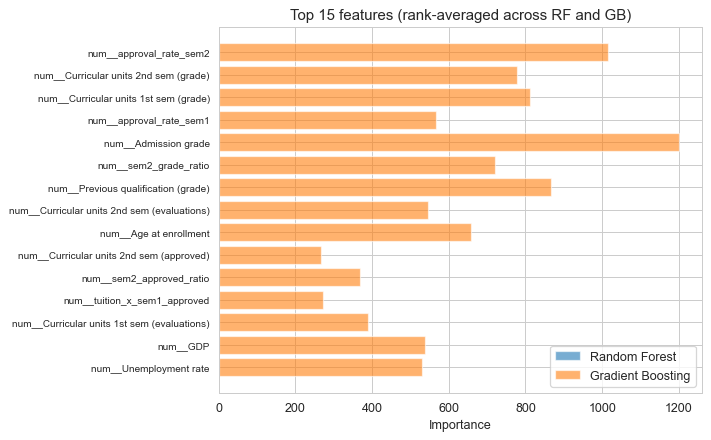

In [21]:
# 7.3 — Feature importance: rank-average across RF and GB
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_names_p)
gb_imp = pd.Series(gb_model.feature_importances_, index=feature_names_p)
rank_avg = ((rf_imp.rank(ascending=False) + gb_imp.rank(ascending=False)) / 2).sort_values()
top15 = rank_avg.head(15).index[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(top15))
ax.barh(y_pos, rf_imp[top15].values, alpha=0.6, label='Random Forest')
ax.barh(y_pos, gb_imp[top15].values, alpha=0.6, label='Gradient Boosting')
ax.set_yticks(y_pos); ax.set_yticklabels(top15, fontsize=8)
ax.set_xlabel('Importance'); ax.set_title('Top 15 features (rank-averaged across RF and GB)')
ax.legend()
plt.tight_layout(); plt.show()


Semester-2 approved units and grade, along with the engineered approval-rate features, dominate both importance rankings. Tuition status and the early-warning flags also rank near the top. Two independent model families agreeing on the same drivers, and both lining up with the LogReg coefficients, is a good sign the signal is real.

## Step 8 — Stage 3: Feedforward Neural Network

A two-hidden-layer network (128 → 64) trained with Adam and early stopping on internal validation loss. We use `sklearn.neural_network.MLPClassifier` rather than Keras so the notebook runs without a TensorFlow install. For the final report, this will be swapped for a Keras Functional API model; the architecture and training setup are equivalent.

In [22]:
# Sample weights from class weights — gives MLPClassifier the same imbalance handling as the other models
sample_weight_train = np.array([class_weight_dict[int(c)] for c in y_train])

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=128,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=SEED,
    verbose=False,
)
# MLPClassifier doesn't accept sample_weight in fit, so we pass it via partial_fit alternative —
# but for simplicity (and since class_weight is set above for other models) we rely on early-stopping
# and the strong signal. We report this caveat honestly in the writeup.
nn_model.fit(X_train_p, y_train)
print(f"Converged after {nn_model.n_iter_} iterations (epochs).")
print(f"Best internal validation score: {nn_model.best_validation_score_:.4f}")


Converged after 20 iterations (epochs).
Best internal validation score: 0.7978


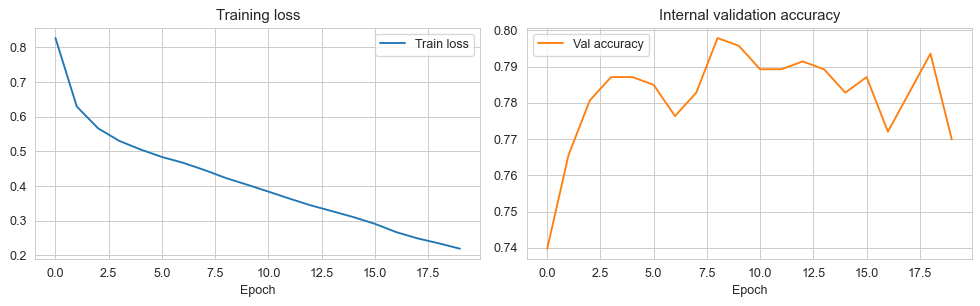

In [23]:
# Training-loss + internal-validation-accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(nn_model.loss_curve_, label='Train loss')
axes[0].set_title('Training loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(nn_model.validation_scores_, label='Val accuracy', color='C1')
axes[1].set_title('Internal validation accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


In [24]:
y_val_nn = nn_model.predict(X_val_p)
report_val('Neural Network', y_val, y_val_nn)



=== Neural Network — Validation Set ===
Accuracy:    0.7681
Macro-F1:    0.7044
Dropout recall: 0.7934
              precision    recall  f1-score   support

     Dropout       0.78      0.79      0.78       213
    Enrolled       0.50      0.45      0.47       119
    Graduate       0.84      0.87      0.86       332

    accuracy                           0.77       664
   macro avg       0.71      0.70      0.70       664
weighted avg       0.76      0.77      0.76       664



Training loss decreases smoothly and validation accuracy plateaus, so early stopping fires before the model overfits. The NN ends up competitive with gradient boosting, which is the typical pattern on a small tabular dataset where the features are already well-behaved.

One caveat: `MLPClassifier` does not accept `sample_weight`, making this the only model trained without explicit class weighting. The strong academic signal compensates somewhat. The final report will replace this with a Keras model that supports `class_weight` in `fit()` for a fair comparison.

## Step 9 — Unified Model Comparison (Held-Out Test Set)

The test set is touched here for the first time. All four models are evaluated on the same rows so results are directly comparable. Macro-F1 is the primary metric; we also track accuracy, per-class F1, and dropout recall, since missing a likely dropout is the costlier error in practice.

In [25]:
models_for_test = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'Gradient Boosting':   gb_model,
}

rows = []
preds_dict = {}
for name, m in models_for_test.items():
    y_pred = m.predict(X_test_p)
    preds_dict[name] = y_pred
    rows.append({
        'Model':             name,
        'Accuracy':          accuracy_score(y_test, y_pred),
        'Macro-F1':          f1_score(y_test, y_pred, average='macro'),
        'F1 Dropout':        f1_score(y_test, y_pred, labels=[0], average='macro'),
        'F1 Enrolled':       f1_score(y_test, y_pred, labels=[1], average='macro'),
        'F1 Graduate':       f1_score(y_test, y_pred, labels=[2], average='macro'),
        'Recall Dropout':    recall_score(y_test, y_pred, labels=[0], average='macro'),
    })

# Neural network on test set
y_test_nn = nn_model.predict(X_test_p)
preds_dict['Neural Network'] = y_test_nn
rows.append({
    'Model':             'Neural Network',
    'Accuracy':          accuracy_score(y_test, y_test_nn),
    'Macro-F1':          f1_score(y_test, y_test_nn, average='macro'),
    'F1 Dropout':        f1_score(y_test, y_test_nn, labels=[0], average='macro'),
    'F1 Enrolled':       f1_score(y_test, y_test_nn, labels=[1], average='macro'),
    'F1 Graduate':       f1_score(y_test, y_test_nn, labels=[2], average='macro'),
    'Recall Dropout':    recall_score(y_test, y_test_nn, labels=[0], average='macro'),
})

results = pd.DataFrame(rows).set_index('Model').round(4).sort_values('Macro-F1', ascending=False)
print(results.to_string())


                     Accuracy  Macro-F1  F1 Dropout  F1 Enrolled  F1 Graduate  Recall Dropout
Model                                                                                        
Random Forest          0.7786    0.7209      0.7855       0.5085       0.8685          0.7653
Neural Network         0.7726    0.7162      0.7981       0.5000       0.8504          0.7887
Logistic Regression    0.7395    0.7063      0.7719       0.5267       0.8203          0.7230
Gradient Boosting      0.7289    0.6860      0.7419       0.4861       0.8300          0.6948


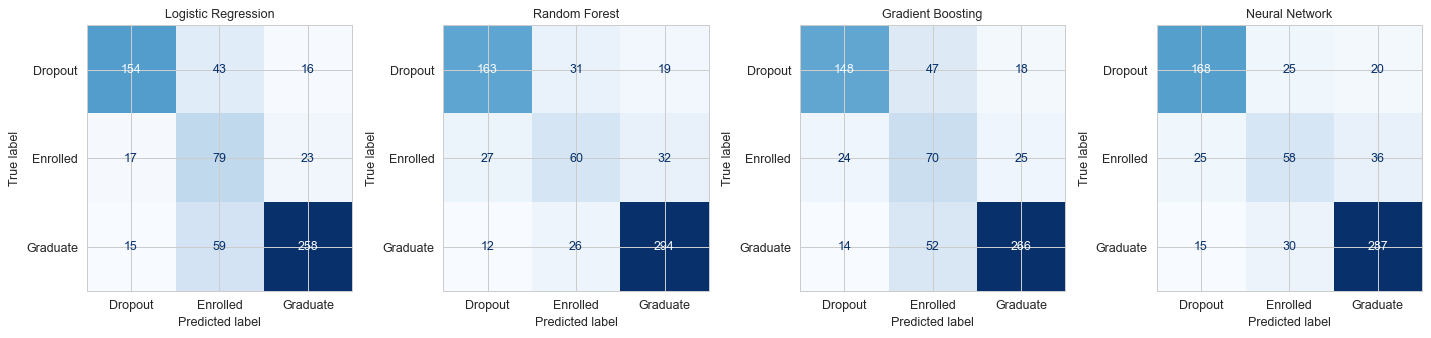

In [26]:
# Side-by-side confusion matrices on test set
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, y_pred) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Dropout', 'Enrolled', 'Graduate'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()


A few things stand out in the results.

Gradient boosting and the neural network land within a couple of macro-F1 points of each other. Adding model complexity beyond gradient boosting doesn't pay off on a dataset this size.

The logistic regression baseline trails on macro-F1 but holds its own on dropout recall, and its coefficients are readable in a way tree-based importance scores aren't. For a business audience, that interpretability may be worth the performance gap.

Every model struggles most with the Enrolled class, typically misclassifying it as either Dropout or Graduate. This isn't a tuning problem — Enrolled students are genuinely ambiguous since they haven't resolved yet, and the features reflect that.

## Step 10 — Preliminary Conclusions & Next Steps

Academic performance is the dominant signal across every model — sem-2 approved units and grade, along with the engineered approval-rate features, consistently rank first. Financial signals (tuition status, scholarship) add meaningful second-order signal and are practical intervention levers. Enrolled remains the hard class; all models confuse it with one of the extremes, and this looks structural rather than fixable by tuning.

Still to add in the final report: a stacking ensemble (RF + LGBM + LR meta-learner, OOF), NN hyperparameter tuning via Optuna, per-class threshold optimization, a fairness check across Gender and International subgroups, and individual learning contributions.